# Predicting and Optimizing Cloud Infrastructure Costs
## MSDS 692 Data Science Practicum I

**Sai Teja Sunku**,Regis University, Spring 2026



The concept of this project is rather straightforward: cloud monthly bills are not very predictable, and the majority of teams tend to spend more than planned due to the lack of awareness of what they actually pay and the reasons for such payment. I would like to build  something that could predict an instance config and inform you what it will cost, approximately, then do some time-series to predict spending every day, and alarm you about something that looks suspicious.


Im using two datasets here:
- **AWS EC2 pricing data** (7,260 rows): for the regression/prediction side and cost optimization analysis (kaggle)
- **Azure anonymized billing data** (93K+ rows): for time series forecasting and anomaly detection on actual daily spending (kaggle)

The two cloud providers I selected are because the actual daily billing data of AWS is not public information (owned by each account). Azure provided anonymized data that I could process. The methods do not differ according to the provider.

### Environment setup

In [1]:
# getting packages installed first
# flaml is microsoft's automl library — handles model selection + hyperparameter tuning
!pip install flaml prophet statsmodels --quiet

In [87]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# just setting some defaults so the plots look ok
plt.rcParams['figure.dpi'] = 100
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

%matplotlib inline

---
## Part 1 AWS EC2 Pricing

Starting with the AWS costs dataset. This has pricing info for EC2 instances across different families, sizes, regions, OS types, and pricing models (on-demand, reserved, spot).

In [5]:
df = pd.read_csv('/Users/saitejasunku/Downloads/data sets/aws_infrastructure_costs.csv')
print(f"shape: {df.shape}")
print(f"cols: {list(df.columns)}")
df.head(3)

shape: (7260, 15)
cols: ['API Name', 'Instance Family', 'Instance Size', 'Category', 'vCPUs', 'Memory (GiB)', 'Network (Gbps)', 'Region', 'Pricing Model', 'OS', 'Hourly Cost ($)', 'Monthly Cost ($)', 'Memory per vCPU (GiB)', 'Cost per vCPU ($/hr)', 'Cost per GiB ($/hr)']


,API Name,Instance Family,Instance Size,Category,vCPUs,Memory (GiB),Network (Gbps),Region,Pricing Model,OS,Hourly Cost ($),Monthly Cost ($),Memory per vCPU (GiB),Cost per vCPU ($/hr),Cost per GiB ($/hr)
0,t3.nano,t3,nano,Burstable,2,0.5,5.0,us-east-1,OnDemand,Linux,0.0052,3.80,0.25,0.0026,0.0104
1,t3.nano,t3,nano,Burstable,2,0.5,5.0,us-east-1,OnDemand,Windows,0.0076,5.55,0.25,0.0038,0.0152
2,t3.nano,t3,nano,Burstable,2,0.5,5.0,us-east-1,OnDemand,RHEL,0.0056,4.09,0.25,0.0028,0.0112


In [6]:
print("missing values per column:")
print(df.isnull().sum())
print(f"\ntotal missing: {df.isnull().sum().sum()}")

missing values per column:
API Name                 0
Instance Family          0
Instance Size            0
Category                 0
vCPUs                    0
Memory (GiB)             0
Network (Gbps)           0
Region                   0
Pricing Model            0
OS                       0
Hourly Cost ($)          0
Monthly Cost ($)         0
Memory per vCPU (GiB)    0
Cost per vCPU ($/hr)     0
Cost per GiB ($/hr)      0
dtype: int64

total missing: 0


In [7]:
df.describe()

,vCPUs,Memory (GiB),Network (Gbps),Hourly Cost ($),Monthly Cost ($),Memory per vCPU (GiB),Cost per vCPU ($/hr),Cost per GiB ($/hr)
count,7260.000000,7260.000000,7260.000000,7260.000000,7260.000000,7260.000000,7260.000000,7260.000000
mean,28.239669,155.390496,14.159091,1.427662,1042.193333,4.960496,0.047722,0.010384
std,30.053548,245.194367,9.142363,2.610887,1905.947756,2.818526,0.054630,0.008483
min,1.000000,0.500000,1.000000,0.001400,1.020000,0.250000,0.000700,0.002000
25%,4.000000,16.000000,10.000000,0.132500,96.730000,2.000000,0.020700,0.004900
50%,16.000000,64.000000,10.000000,0.571000,416.830000,4.000000,0.033100,0.007900
75%,48.000000,192.000000,18.750000,1.742200,1271.810000,8.000000,0.055200,0.012700
max,128.000000,1952.000000,50.000000,42.889000,31308.970000,15.250000,0.670100,0.087900


In [8]:
print(f"Instance Families: {df['Instance Family'].nunique()} unique")
print(f"Regions: {list(df['Region'].unique())}")
print(f"Pricing Models: {list(df['Pricing Model'].unique())}")
print(f"OS: {list(df['OS'].unique())}")
print(f"Categories: {list(df['Category'].unique())}")

Instance Families: 18 unique
Regions: ['us-east-1', 'us-west-2', 'eu-west-1', 'ap-southeast-1', 'ap-northeast-1']
Pricing Models: ['OnDemand', 'Reserved-1yr', 'Reserved-3yr', 'Spot']
OS: ['Linux', 'Windows', 'RHEL']
Categories: ['Burstable', 'General Purpose', 'Compute Optimized', 'Memory Optimized', 'Storage Optimized', 'Accelerated Computing']


### EDA: understanding the pricing landscape

Prior to modeling anything, I would like to observe the cost distributions. Since the majority of instances are small to medium-sized and only a small number are massive compute-optimized, my intuition is that it will be strongly skewed to the right.

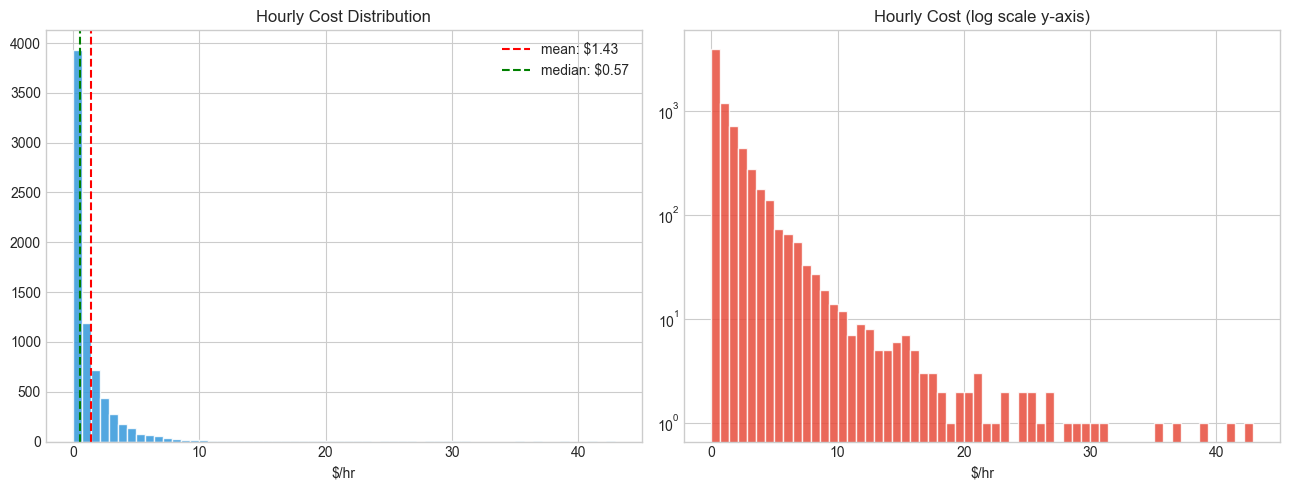

 $0.57 but mean is $1.43


In [88]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df["Hourly Cost ($)"], bins=60, color="#3498db", edgecolor="white", alpha=0.85)
avg_h = df["Hourly Cost ($)"].mean()
med_h = df["Hourly Cost ($)"].median()
axes[0].axvline(avg_h, color="red", ls="--", label=f"mean: ${avg_h:.2f}")
axes[0].axvline(med_h, color="green", ls="--", label=f"median: ${med_h:.2f}")
axes[0].set_title("Hourly Cost Distribution")
axes[0].set_xlabel("$/hr"); axes[0].legend()

axes[1].hist(df["Hourly Cost ($)"], bins=60, color="#e74c3c", edgecolor="white", alpha=0.85)
axes[1].set_yscale("log")
axes[1].set_title("Hourly Cost (log scale y-axis)")
axes[1].set_xlabel("$/hr")

plt.tight_layout()
plt.show()
print(f" ${med_h:.2f} but mean is ${avg_h:.2f}")

In [48]:
print(f"skewness: {df['Hourly Cost ($)'].skew():.2f}")
print(f"kurtosis: {df['Hourly Cost ($)'].kurtosis():.2f}")

skewness: 5.97
kurtosis: 56.86


Let's compare the actual savings between reserved, spot, and on-demand. For FinOps, this is the crucial component.

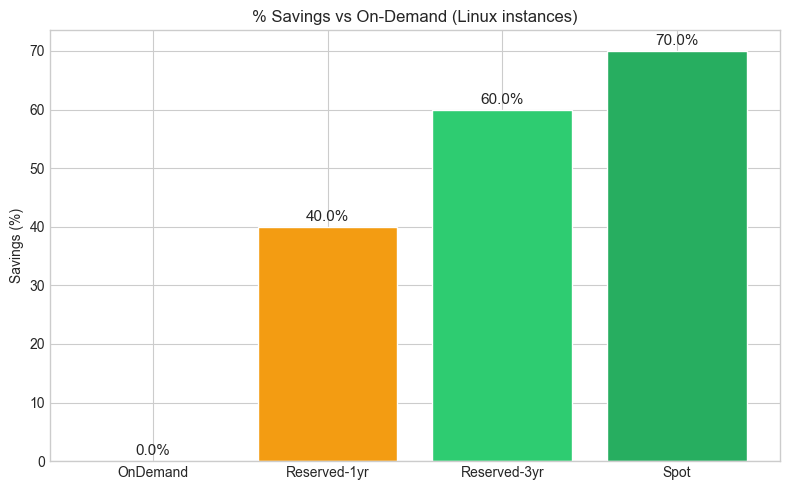

In [49]:
linux_df = df[df["OS"] == "Linux"]
pm_means = linux_df.groupby("Pricing Model")["Hourly Cost ($)"].mean()
od_avg = pm_means.get("OnDemand", pm_means.max())

savings = {}
for pm, cost in pm_means.items():
    savings[pm] = round((od_avg - cost) / od_avg * 100, 1)

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = {"OnDemand": "#e74c3c", "Reserved-1yr": "#f39c12", "Reserved-3yr": "#2ecc71", "Spot": "#27ae60"}
bars = ax.bar(savings.keys(), savings.values(), 
              color=[colors_bar.get(k, "#95a5a6") for k in savings.keys()], edgecolor="white")
ax.set_title("% Savings vs On-Demand (Linux instances)")
ax.set_ylabel("Savings (%)")

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

We are now examining regional variations in costs. Since us-east-1 is the default and most widely used, I anticipate it being the least expensive.

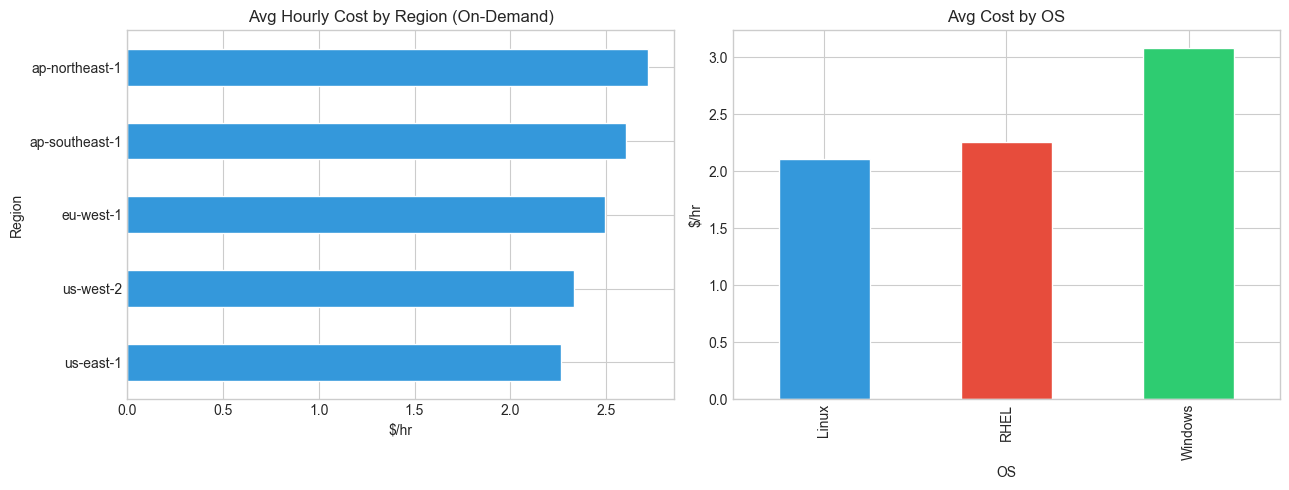

Windows premium over Linux: 46.0%


In [52]:
od = df[df["Pricing Model"] == "OnDemand"]
region_avg = od.groupby("Region")["Hourly Cost ($)"].mean().sort_values()
baseline = region_avg.iloc[0]  # cheapest region

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

region_avg.plot(kind="barh", ax=axes[0], color="#3498db", edgecolor="white")
axes[0].set_title("Avg Hourly Cost by Region (On-Demand)")
axes[0].set_xlabel("$/hr")

os_comp = od.groupby("OS")["Hourly Cost ($)"].mean()
os_comp.plot(kind="bar", ax=axes[1], color=["#3498db", "#e74c3c", "#2ecc71"], edgecolor="white")
axes[1].set_title("Avg Cost by OS")
axes[1].set_ylabel("$/hr")

plt.tight_layout()
plt.show()

if "Windows" in os_comp.index and "Linux" in os_comp.index:
    win_prem = (os_comp["Windows"] - os_comp["Linux"]) / os_comp["Linux"] * 100
    print(f"Windows premium over Linux: {win_prem:.1f}%")

Before developing the model, a quick correlation check is necessary to determine which features drive cost the most.

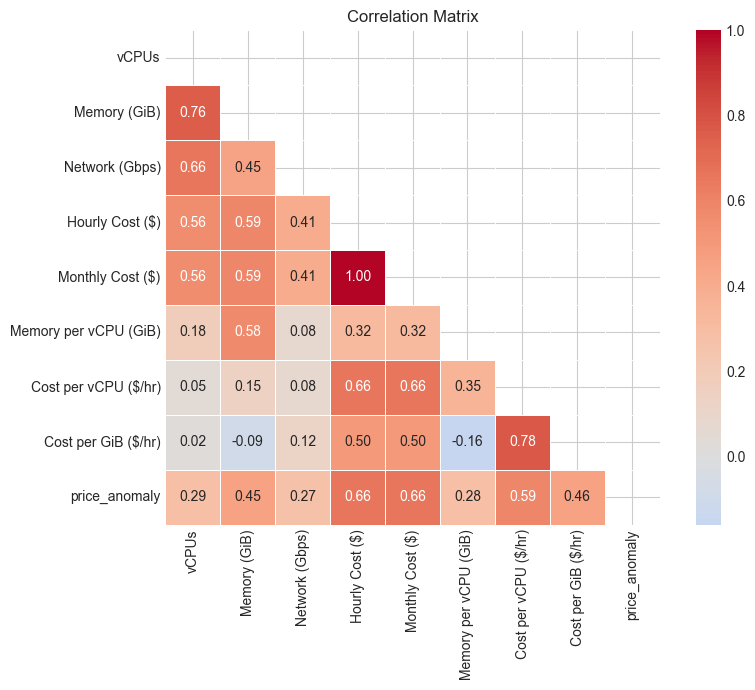


Correlations with Hourly Cost:
  Monthly Cost ($)               +1.000
  Cost per vCPU ($/hr)           +0.663
  price_anomaly                  +0.659
  Memory (GiB)                   +0.588
  vCPUs                          +0.558
  Cost per GiB ($/hr)            +0.495
  Network (Gbps)                 +0.406
  Memory per vCPU (GiB)          +0.316


In [53]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_mat = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("\nCorrelations with Hourly Cost:")
cost_corr = corr_mat["Hourly Cost ($)"].drop("Hourly Cost ($)").sort_values(ascending=False)
for feat, val in cost_corr.items():
    print(f"  {feat:30s} {val:+.3f}")

To see the true relationships, use scatter plots. filtering to on-demand Linux US-East-1 to avoid confusing pricing model, region, or OS.

filtered subset: 121 rows


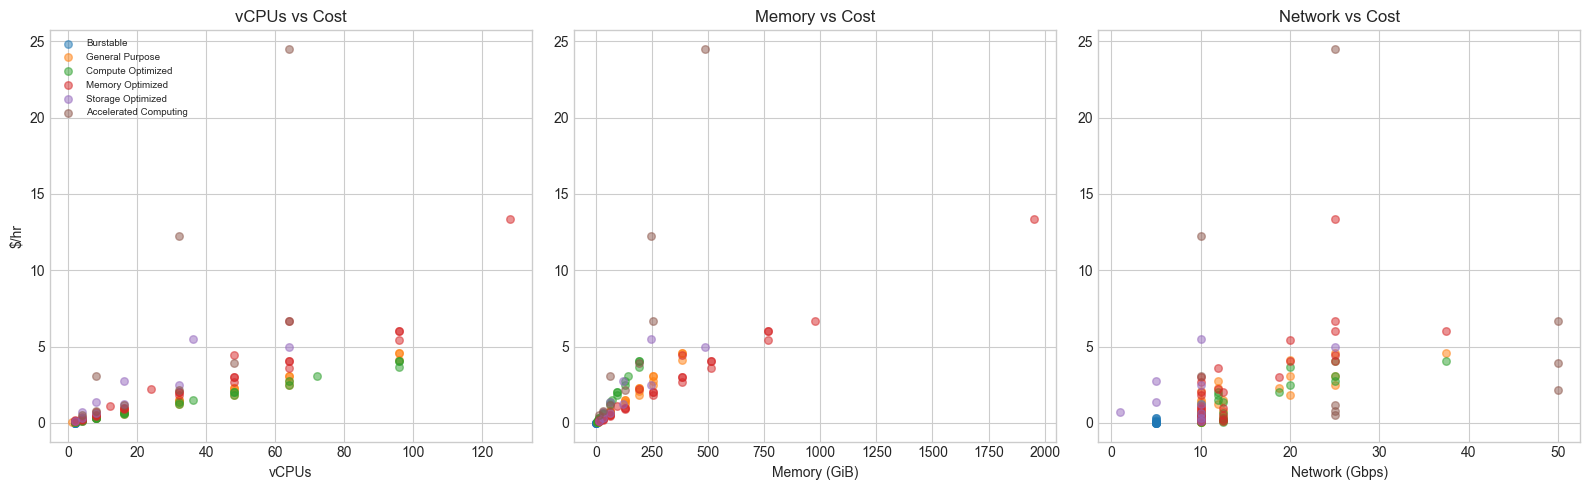

In [54]:
od_linux_east = df[(df["Pricing Model"]=="OnDemand") & (df["OS"]=="Linux") & (df["Region"]=="us-east-1")]
print(f"filtered subset: {len(od_linux_east)} rows")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for cat in od_linux_east["Category"].unique():
    sub = od_linux_east[od_linux_east["Category"]==cat]
    axes[0].scatter(sub["vCPUs"], sub["Hourly Cost ($)"], alpha=0.5, s=30, label=cat)
    axes[1].scatter(sub["Memory (GiB)"], sub["Hourly Cost ($)"], alpha=0.5, s=30)
    axes[2].scatter(sub["Network (Gbps)"], sub["Hourly Cost ($)"], alpha=0.5, s=30)

axes[0].set_xlabel("vCPUs"); axes[0].set_ylabel("$/hr"); axes[0].set_title("vCPUs vs Cost")
axes[0].legend(fontsize=7, loc="upper left")
axes[1].set_xlabel("Memory (GiB)"); axes[1].set_title("Memory vs Cost")
axes[2].set_xlabel("Network (Gbps)"); axes[2].set_title("Network vs Cost")
plt.tight_layout()
plt.show()

---
### AutoML Regression

Alright, so this is the primary modeling section. I'm using Microsoft's automl library, called FLAML (Fast and Lightweight AutoML). To find the best model, it automatically searches through several algorithms, such as LightGBM, XGBoost, Random Forest, Extra Trees, etc., and adjusts hyperparameters. Basically, all you have to do is give it the task type and a time budget, and it will take care of the rest.

Since Flaml requires numerical inputs, I must first encode the categorical columns.

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

feature_cols = ["vCPUs", "Memory (GiB)", "Network (Gbps)", "Memory per vCPU (GiB)",
                "Instance Family", "Instance Size", "Category", "Region", "Pricing Model", "OS"]
target = "Hourly Cost ($)"

model_df = df[feature_cols + [target]].copy()

encoders = {}
cat_cols = ["Instance Family", "Instance Size", "Category", "Region", "Pricing Model", "OS"]
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    encoders[col] = le
    print(f"  encoded {col}: {le.classes_.shape[0]} categories")

X = model_df.drop(target, axis=1)
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\ntrain: {X_train.shape}, test: {X_test.shape}")

  encoded Instance Family: 18 categories
  encoded Instance Size: 17 categories
  encoded Category: 6 categories
  encoded Region: 5 categories
  encoded Pricing Model: 4 categories
  encoded OS: 3 categories

train: (5808, 10), test: (1452, 10)


Now running FLAML. Giving it 120 seconds  it will try as many model + hyperparameter combos as it can in that time and pick the best one.

I initially tried including all columns but FLAML threw an error because some string columns
werent encoded. Had to go back and add LabelEncoder for the categorical features.

In [56]:
from flaml import AutoML

automl = AutoML()

automl.fit(
    X_train, y_train,
    task="regression",
    metric="r2",
    time_budget=180,
    estimator_list=["catboost", "xgboost", "rf", "extra_tree"],
    verbose=0,
    seed=42,
)

print(f"best model type: {automl.best_estimator}")
print(f"best config: {automl.best_config}")

best model type: catboost
best config: {'early_stopping_rounds': 19, 'learning_rate': 0.057068486286479744, 'n_estimators': 8192}


In [58]:
print(f"best estimator: {automl.best_estimator}")
print(f"best R² (CV): {automl.best_loss:.6f}" if hasattr(automl, 'best_loss') else "")
print(f"\nbest hyperparameters:")
for k, v in automl.best_config.items():
    print(f"  {k}: {v}")

best estimator: catboost
best R² (CV): 0.000347

best hyperparameters:
  early_stopping_rounds: 19
  learning_rate: 0.057068486286479744
  n_estimators: 8192


Now testing on the held-out set that automl never saw during training.

In [1]:
best = automl.model
y_pred = best.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
nz = y_test > 0.001
mape = np.mean(np.abs((y_test[nz] - y_pred[nz]) / y_test[nz])) * 100

print(f"model type: {type(best).__name__}")
print(f"R²:    {r2:.6f}")
print(f"MAE:   ${mae:.4f}/hr")
print(f"RMSE:  ${rmse:.4f}/hr")
print(f"MAPE:  {mape:.2f}%")
print()
if r2 > 0.80:
    print(f"target was R² > 0.80  we hit {r2:.4f}, so thats good")
else:
    print(f"R² is {r2:.4f}, below 0.80 target — might need more tuning")

NameError: name 'automl' is not defined

Plotting actual vs predicted. If the model is any good these should cluster along the diagonal.

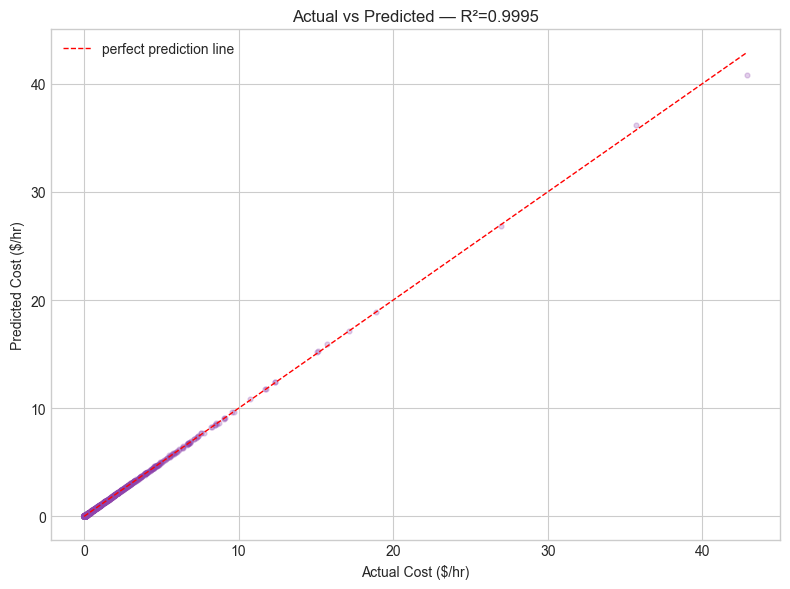

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.25, s=12, c="#8e44ad")
max_val = max(y_test.max(), y_pred.max())
ax.plot([0, max_val], [0, max_val], "r--", lw=1, label="perfect prediction line")
ax.set_xlabel("Actual Cost ($/hr)")
ax.set_ylabel("Predicted Cost ($/hr)")
ax.set_title(f"Actual vs Predicted — R²={r2:.4f}")
ax.legend()
plt.tight_layout()
plt.show()

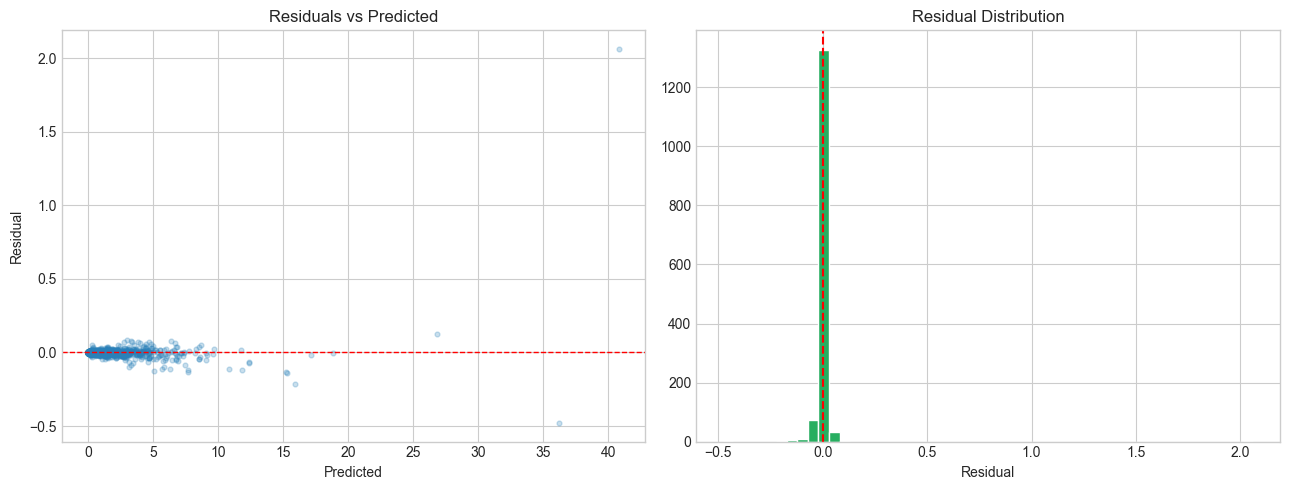

residual mean: -0.000225 (should be ~0)
residual std:  0.0586


In [61]:
resid = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_pred, resid, alpha=0.25, s=12, c="#2980b9")
axes[0].axhline(0, color="red", ls="--", lw=1)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(resid, bins=50, color="#27ae60", edgecolor="white")
axes[1].set_xlabel("Residual"); axes[1].set_title("Residual Distribution")
axes[1].axvline(0, color="red", ls="--")

plt.tight_layout()
plt.show()
print(f"residual mean: {resid.mean():.6f} (should be ~0)")
print(f"residual std:  {resid.std():.4f}")

Feature importance curious which features the model relies on most.

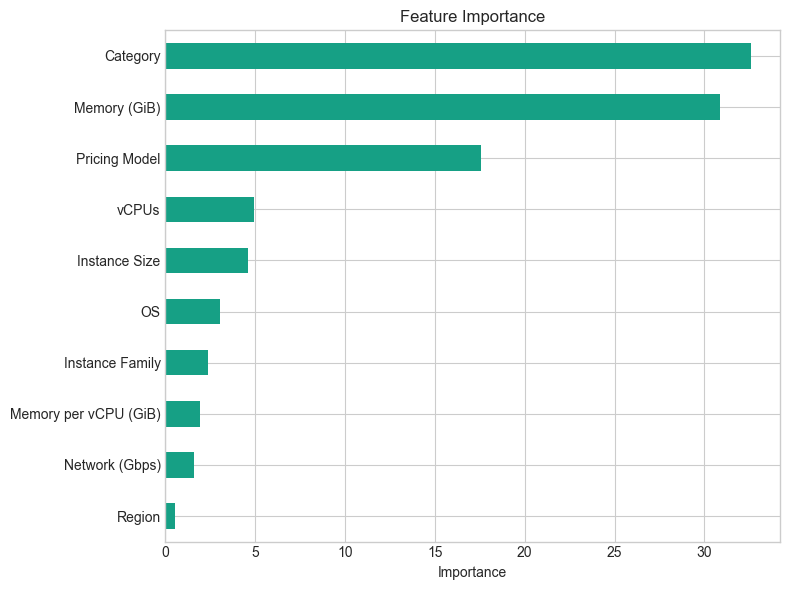

In [62]:
try:
    imp = best.feature_importances_
    fi = pd.Series(imp, index=X_train.columns).sort_values()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    fi.plot(kind="barh", color="#16a085", ax=ax)
    ax.set_title("Feature Importance")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()
except AttributeError:
    try:
        coefs = best.coef_
        fi = pd.Series(np.abs(coefs), index=X_train.columns).sort_values()
        fi.plot(kind="barh", color="#16a085")
        plt.title("Feature Coefficients (abs)")
        plt.tight_layout()
        plt.show()
    except:
        print("this model type doesnt give feature importances directly, skipping")

---
### Pricing Anomaly Detection

This is an alternate form of anomaly detection  i am seeking overpriced instances compared to specification. Similar, in case two instances share comparable vCPUs and memory yet one is much more expensive, that is an exception that should be pointed out.

Isolation Forest is the method used in this case because it is an effective way to detect multivariate anomalies, and it does not require labeled data.

In [64]:
from sklearn.ensemble import IsolationForest

value_cols = ["vCPUs", "Memory (GiB)", "Network (Gbps)", 
              "Hourly Cost ($)", "Cost per vCPU ($/hr)", "Cost per GiB ($/hr)"]

iso_price = IsolationForest(
    contamination=0.05,  
    random_state=42, 
    n_estimators=200
)
df["price_anomaly"] = iso_price.fit_predict(df[value_cols])
df["price_anomaly"] = (df["price_anomaly"] == -1).astype(int)  # 1 = anomaly

n_anom = df["price_anomaly"].sum()
print(f"flagged {n_anom} pricing anomalies out of {len(df)} ({n_anom/len(df)*100:.1f}%)")

print(f"\nnormal instances avg cost:  ${df[df['price_anomaly']==0]['Hourly Cost ($)'].mean():.2f}/hr")
print(f"anomaly instances avg cost: ${df[df['price_anomaly']==1]['Hourly Cost ($)'].mean():.2f}/hr")

flagged 363 pricing anomalies out of 7260 (5.0%)

normal instances avg cost:  $1.03/hr
anomaly instances avg cost: $8.92/hr


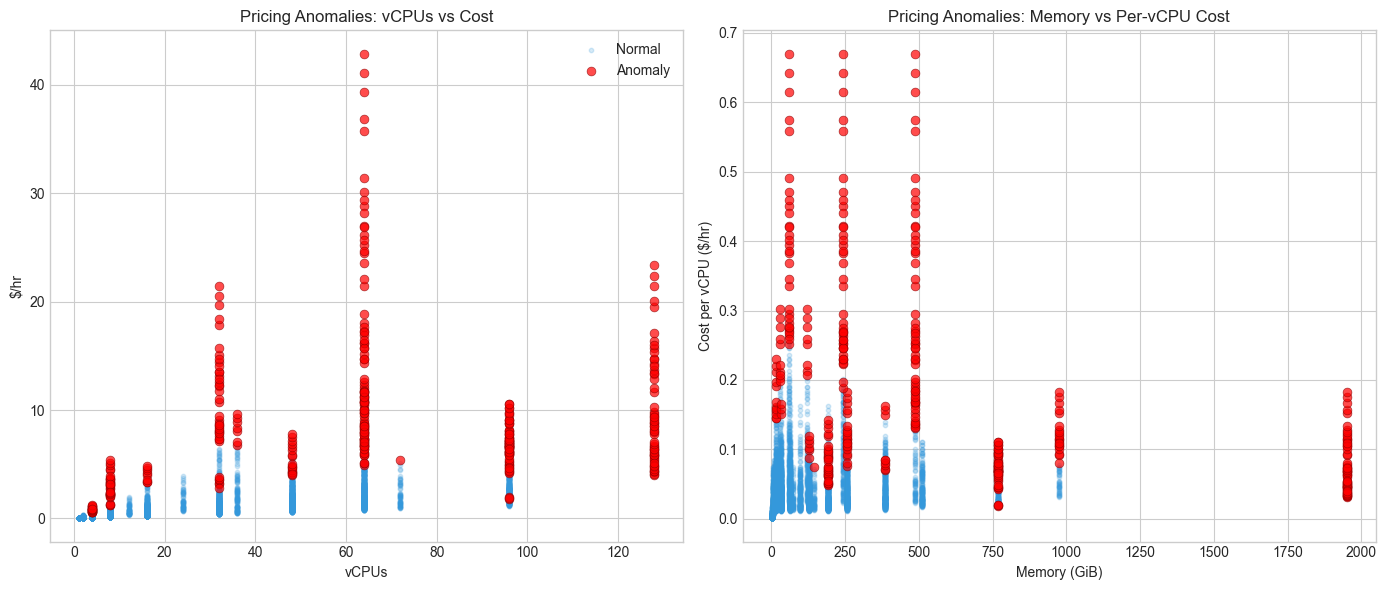

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

norm = df[df["price_anomaly"]==0]
anom = df[df["price_anomaly"]==1]

axes[0].scatter(norm["vCPUs"], norm["Hourly Cost ($)"], alpha=0.2, s=10, c="#3498db", label="Normal")
axes[0].scatter(anom["vCPUs"], anom["Hourly Cost ($)"], alpha=0.7, s=40, c="red", 
                label="Anomaly", edgecolors="darkred", linewidth=0.5)
axes[0].set_xlabel("vCPUs"); axes[0].set_ylabel("$/hr")
axes[0].set_title("Pricing Anomalies: vCPUs vs Cost")
axes[0].legend()

axes[1].scatter(norm["Memory (GiB)"], norm["Cost per vCPU ($/hr)"], alpha=0.2, s=10, c="#3498db")
axes[1].scatter(anom["Memory (GiB)"], anom["Cost per vCPU ($/hr)"], alpha=0.7, s=40, c="red", edgecolors="darkred", linewidth=0.5)
axes[1].set_xlabel("Memory (GiB)"); axes[1].set_ylabel("Cost per vCPU ($/hr)")
axes[1].set_title("Pricing Anomalies: Memory vs Per-vCPU Cost")

plt.tight_layout()
plt.show()

In [66]:
print(anom["Category"].value_counts().to_string())
print("\nanomalies by pricing model:")
print(anom["Pricing Model"].value_counts().to_string())

Category
Accelerated Computing    174
Memory Optimized         132
Storage Optimized         32
Compute Optimized         19
General Purpose            6

anomalies by pricing model:
Pricing Model
OnDemand        220
Reserved-1yr     79
Reserved-3yr     36
Spot             28


---
### Cost Optimization Analysis

This is the practical takeaway  if youre running workloads on AWS, how much can you save by picking the right pricing model and instance family?

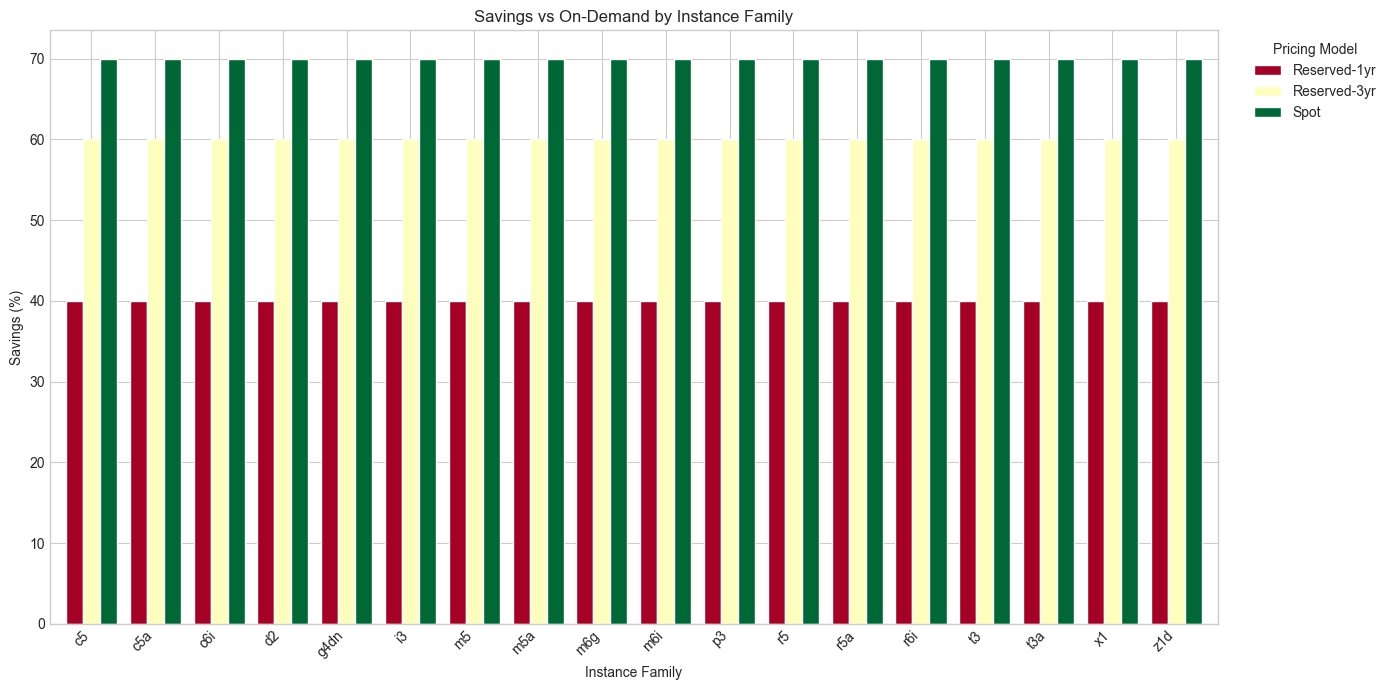

In [67]:
pivot = df.pivot_table(values="Monthly Cost ($)", index="Instance Family", 
                       columns="Pricing Model", aggfunc="mean")

if "OnDemand" in pivot.columns:
    pct_of_od = pivot.div(pivot["OnDemand"], axis=0) * 100
    savings_pct = 100 - pct_of_od
    alt_models = [c for c in savings_pct.columns if c != "OnDemand"]
    
    fig, ax = plt.subplots(figsize=(14, 7))
    savings_pct[alt_models].plot(kind="bar", ax=ax, colormap="RdYlGn", edgecolor="white", width=0.8)
    ax.set_title("Savings vs On-Demand by Instance Family")
    ax.set_ylabel("Savings (%)")
    ax.set_xlabel("Instance Family")
    ax.legend(title="Pricing Model", bbox_to_anchor=(1.02, 1))
    ax.axhline(0, color="black", lw=0.5)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

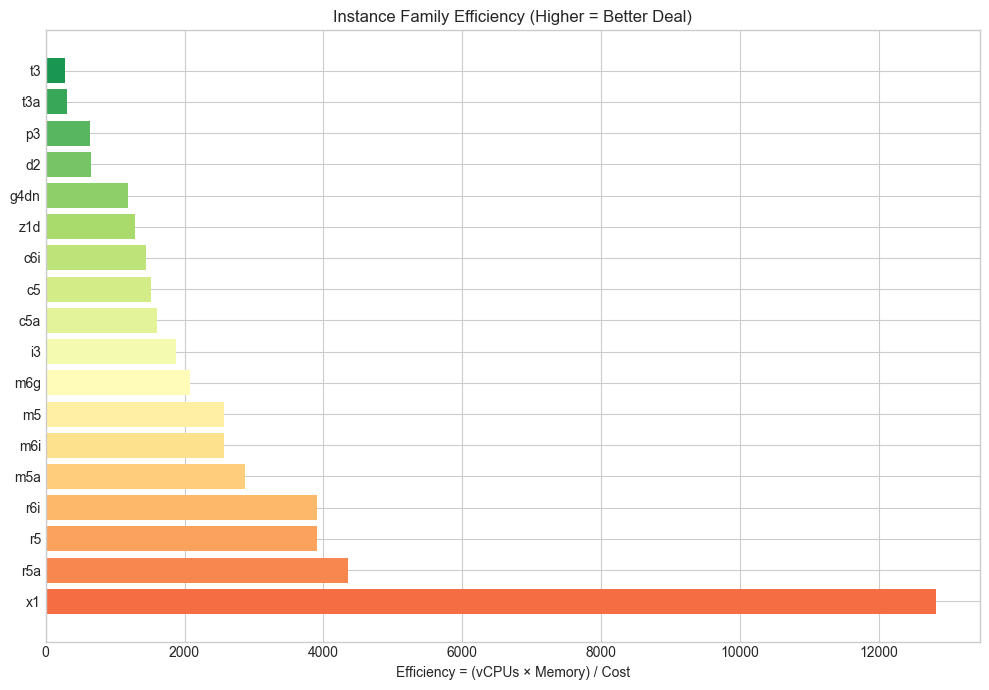

Instance Family  avg_vcpus  avg_mem  avg_cost   efficiency
             x1      96.00   1464.0 10.963830 12818.878075
            r5a      33.75    270.0  2.089935  4360.183451
             r5      33.75    270.0  2.330370  3910.323253
            r6i      33.75    270.0  2.330370  3910.323253
            m5a      33.75    135.0  1.590570  2864.539127


In [68]:
od_linux = df[(df["Pricing Model"]=="OnDemand") & (df["OS"]=="Linux")]
eff = od_linux.groupby("Instance Family").agg(
    avg_vcpus=("vCPUs", "mean"),
    avg_mem=("Memory (GiB)", "mean"),
    avg_cost=("Hourly Cost ($)", "mean")
).reset_index()
eff["efficiency"] = (eff["avg_vcpus"] * eff["avg_mem"]) / eff["avg_cost"]
eff = eff.sort_values("efficiency", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors_eff = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(eff)))
ax.barh(eff["Instance Family"], eff["efficiency"], color=colors_eff)
ax.set_title("Instance Family Efficiency (Higher = Better Deal)")
ax.set_xlabel("Efficiency = (vCPUs × Memory) / Cost")
plt.tight_layout()
plt.show()

print(eff.head().to_string(index=False))

In [69]:
od_monthly_avg = df[df["Pricing Model"]=="OnDemand"]["Monthly Cost ($)"].mean()
for pm in ["Reserved-1yr", "Reserved-3yr", "Spot"]:
    pm_avg = df[df["Pricing Model"]==pm]["Monthly Cost ($)"].mean()
    sav = (od_monthly_avg - pm_avg) / od_monthly_avg * 100
    dollar_sav = od_monthly_avg - pm_avg
    print(f"  {pm:15s}: {sav:.1f}% (${dollar_sav:.2f}/mo per instance)")

  Reserved-1yr   : 40.0% ($725.00/mo per instance)
  Reserved-3yr   : 60.0% ($1087.51/mo per instance)
  Spot           : 70.0% ($1268.76/mo per instance)


---
## Part 2  Azure Cloud Billing Data (Time Series)

Switching gears to the Azure anonymized billing dataset. This has 93K+ line items across 50 cloud services over about 3 months of actual usage. I aggregate it to daily totals for forecasting.

Quick note on why Azure and not AWS: daily cloud billing data is proprietary  AWS doesnt publish it. This anonymized Azure dataset is one of the few real billing datasets publicly available. The forecasting and anomaly detection techniques are identical regardless of which cloud provider the data comes from.

In [71]:
az = pd.read_csv("/Users/saitejasunku/Downloads/data sets/anonymized_costs.csv")
az["Date"] = pd.to_datetime(az["Date"])

print(f"loaded {az.shape[0]:,} rows")
print(f"date range: {az['Date'].min().date()} to {az['Date'].max().date()}")
print(f"unique services: {az['MeterCategory'].nunique()}")
print(f"unique days: {az['Date'].dt.date.nunique()}")

daily = az.groupby("Date")["CostInBillingCurrency"].sum().reset_index()
daily.columns = ["ds", "y"]
daily = daily.sort_values("ds").reset_index(drop=True)

print(f"\ndaily cost: ${daily['y'].min():.2f} to ${daily['y'].max():.2f}")
print(f"mean: ${daily['y'].mean():.2f}/day")
print(f"total data points: {len(daily)}")

loaded 93,605 rows
date range: 2022-12-22 to 2023-03-20
unique services: 50
unique days: 89

daily cost: $69.55 to $169.61
mean: $107.21/day
total data points: 89


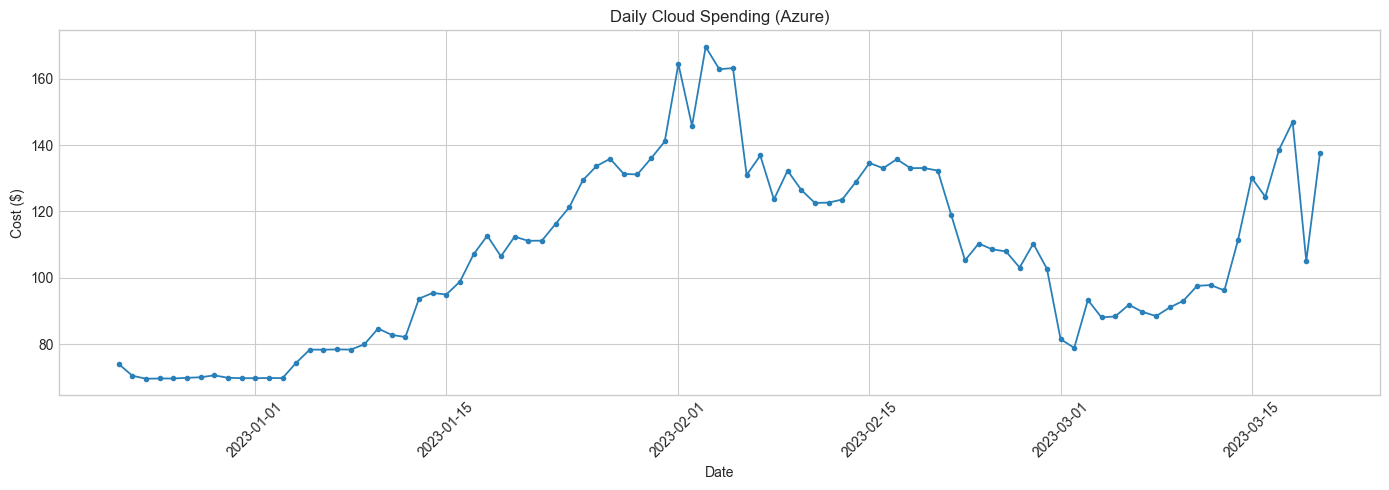

In [73]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily["ds"], daily["y"], color="#2980b9", lw=1.3, marker="o", markersize=3)
ax.set_title("Daily Cloud Spending (Azure)")
ax.set_ylabel("Cost ($)"); ax.set_xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

What services are eating most of the budget?

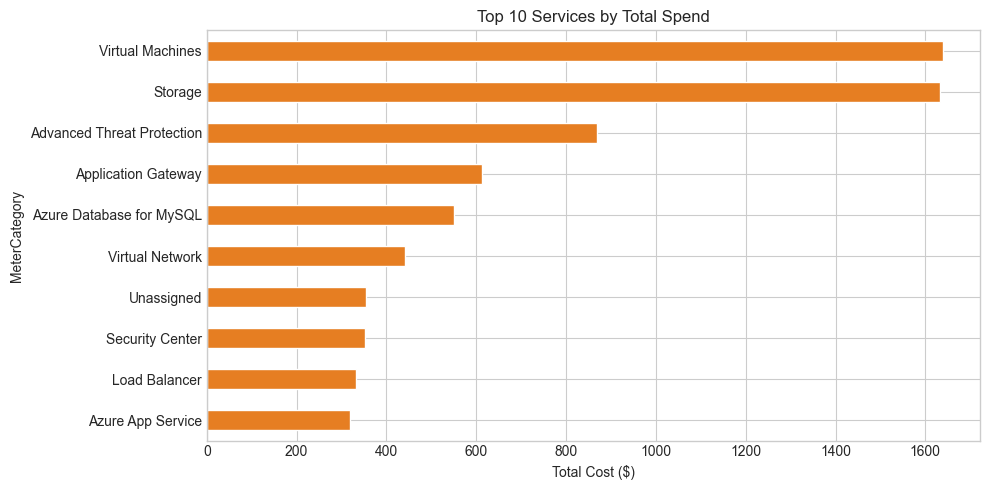

top 5 services as % of total spend:
  Virtual Machines               $ 1639.66  (17.2%)
  Storage                        $ 1631.55  (17.1%)
  Advanced Threat Protection     $  868.07  (9.1%)
  Application Gateway            $  613.66  (6.4%)
  Azure Database for MySQL       $  551.50  (5.8%)


In [74]:
svc_totals = az.groupby("MeterCategory")["CostInBillingCurrency"].sum().sort_values(ascending=False)
top10 = svc_totals.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top10.plot(kind="barh", ax=ax, color="#e67e22", edgecolor="white")
ax.set_title("Top 10 Services by Total Spend")
ax.set_xlabel("Total Cost ($)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

total_spend = svc_totals.sum()
print("top 5 services as % of total spend:")
for svc, cost in svc_totals.head(5).items():
    print(f"  {svc:30s} ${cost:>8.2f}  ({cost/total_spend*100:.1f}%)")

---
### Time Series Forecasting

Splitting 75/25  train on the first ~67 days, test on the last ~22. I know 89 data points isnt a ton, but its enough for Prophet and ARIMA to work with, especially since theres a clear trend.

In [75]:
split = int(len(daily) * 0.75)
train = daily.iloc[:split].copy()
test  = daily.iloc[split:].copy()
print(f"train: {len(train)} days ({train['ds'].min().date()} to {train['ds'].max().date()})")
print(f"test:  {len(test)} days ({test['ds'].min().date()} to {test['ds'].max().date()})")

train: 66 days (2022-12-22 to 2023-02-25)
test:  23 days (2023-02-26 to 2023-03-20)


**Prophet**

Facebook Prophet has a great knack in auto-handling trends and changepoints. I am switching off yearly seasonality because we only have 3 months of data that would not be reasonable. Weekly seasonality has not been removed because there is a tendency of cloud use declining on weekends.

In [76]:
from prophet import Prophet

m = Prophet(
    yearly_seasonality=False,   
    weekly_seasonality=True,   
    daily_seasonality=False,
    changepoint_prior_scale=0.3,  
    seasonality_mode="additive",
)
m.fit(train)

future = m.make_future_dataframe(periods=len(test), freq="D")
fcast = m.predict(future)

p_pred = fcast.iloc[split:]["yhat"].values
p_lower = fcast.iloc[split:]["yhat_lower"].values
p_upper = fcast.iloc[split:]["yhat_upper"].values
actual = test["y"].values

p_mae  = mean_absolute_error(actual, p_pred)
p_rmse = np.sqrt(mean_squared_error(actual, p_pred))
p_mape = np.mean(np.abs((actual - p_pred) / actual)) * 100

print(f"Prophet results:")
print(f"  MAE:  ${p_mae:.2f}")
print(f"  RMSE: ${p_rmse:.2f}")
print(f"  MAPE: {p_mape:.2f}%")

18:06:46 - cmdstanpy - INFO - Chain [1] start processing
18:06:46 - cmdstanpy - INFO - Chain [1] done processing


Prophet results:
  MAE:  $20.34
  RMSE: $27.64
  MAPE: 18.06%


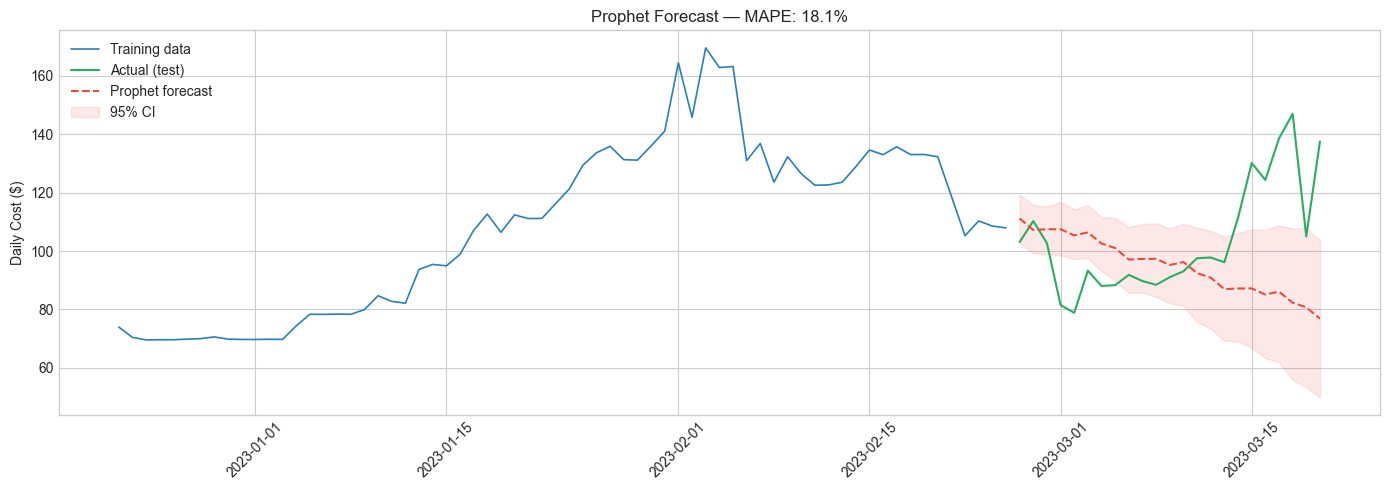

In [77]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train["ds"], train["y"], color="#2980b9", lw=1.2, label="Training data")
ax.plot(test["ds"], actual, color="#27ae60", lw=1.5, label="Actual (test)")
ax.plot(test["ds"], p_pred, color="#e74c3c", lw=1.5, ls="--", label="Prophet forecast")
ax.fill_between(test["ds"], p_lower, p_upper, color="#e74c3c", alpha=0.12, label="95% CI")
ax.set_title(f"Prophet Forecast — MAPE: {p_mape:.1f}%")
ax.set_ylabel("Daily Cost ($)"); ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

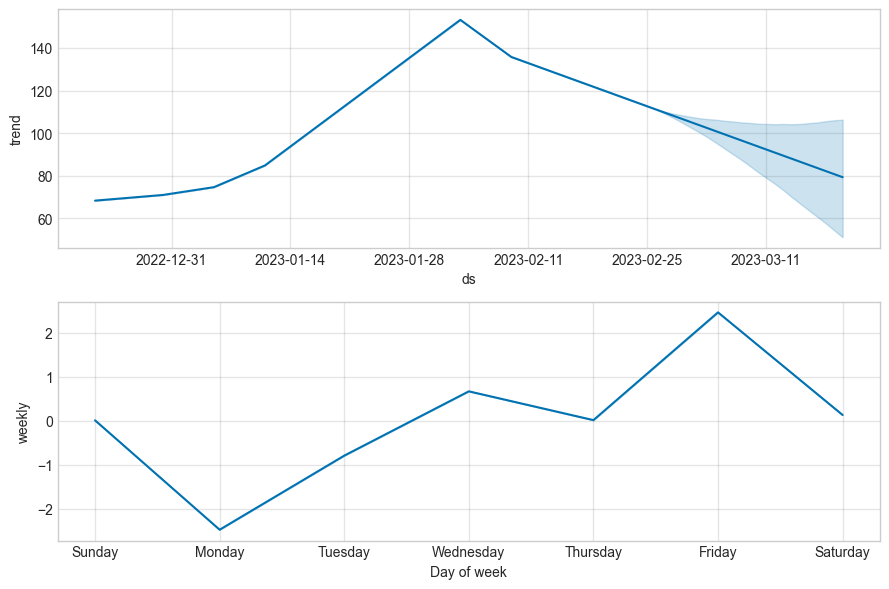

In [78]:
m.plot_components(fcast)
plt.tight_layout()
plt.show()

**ARIMA**

More traditional approach. To check the stationarity, ADF test first with that upward trend its likely to be non-stationary and hence I will have to difference it.

-1.4850
p-value: 0.5409
non-stationary — need differencing (d=1)


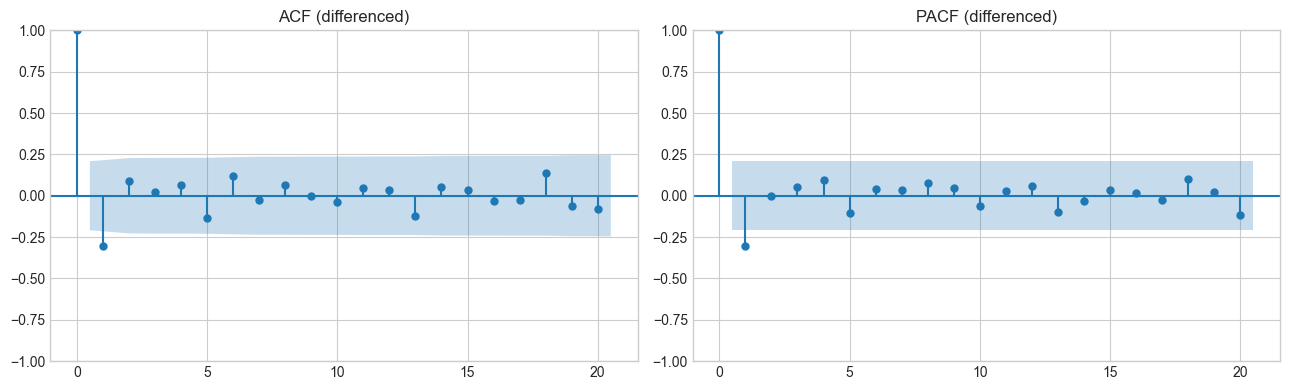

In [80]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

adf_result = adfuller(daily["y"])
print(f"{adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
if adf_result[1] < 0.05:
    print("stationary (reject null)")
else:
    print("non-stationary — need differencing (d=1)")

diff = daily["y"].diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(diff, lags=20, ax=axes[0])
axes[0].set_title("ACF (differenced)")
plot_pacf(diff, lags=20, ax=axes[1])
axes[1].set_title("PACF (differenced)")
plt.tight_layout()
plt.show()

In [38]:
train_vals = train["y"].values
test_vals  = test["y"].values

arima = ARIMA(train_vals, order=(2, 1, 2))
arima_fit = arima.fit()

a_pred = arima_fit.forecast(steps=len(test_vals))

a_mae  = mean_absolute_error(test_vals, a_pred)
a_rmse = np.sqrt(mean_squared_error(test_vals, a_pred))
a_mape = np.mean(np.abs((test_vals - a_pred) / test_vals)) * 100

print(f"ARIMA(2,1,2) results:")
print(f"  MAE:  ${a_mae:.2f}")
print(f"  RMSE: ${a_rmse:.2f}")
print(f"  MAPE: {a_mape:.2f}%")

ARIMA(2,1,2) results:
  MAE:  $16.72
  RMSE: $19.33
  MAPE: 16.40%


In [2]:
# I also tried (1,1,1) and (5,1,2) (1,1,1) was worse,
# (5,1,2) was slightly overfit. (2,1,2) seemed like the sweet spot
# based on the ACF/PACF lags above
# arima_alt = ARIMA(train_vals, order=(1,1,1))
# alt_fit = arima_alt.fit()
# alt_pred = alt_fit.forecast(steps=len(test_vals))
# print(f"ARIMA(1,1,1) MAPE: {np.mean(np.abs((test_vals - alt_pred)/test_vals))*100:.2f}%")
# was like 18% so definitely worse

In [81]:
# arima summary stats
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   66
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -216.902
Date:                Wed, 04 Mar 2026   AIC                            443.804
Time:                        18:24:45   BIC                            454.676
Sample:                             0   HQIC                           448.094
                                 - 66                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.5735      0.079    -19.969      0.000      -1.728      -1.419
ar.L2         -0.7617      0.081     -9.432      0.000      -0.920      -0.603
ma.L1          1.6415     22.036      0.074      0.9

**Head-to-head comparison**

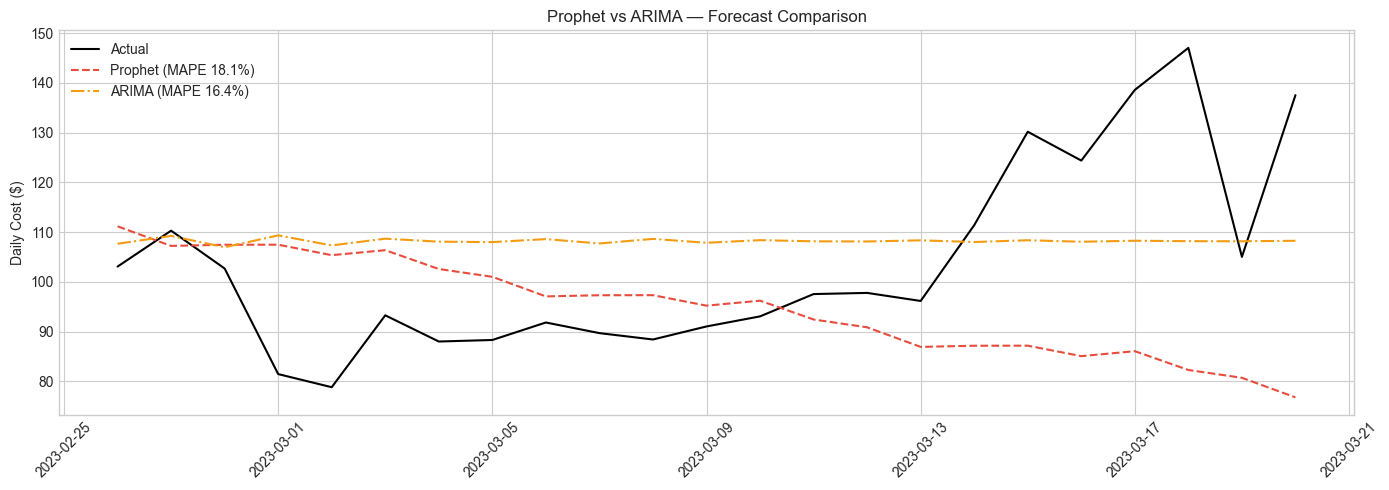

Model                   MAE ($)   RMSE ($)   MAPE (%)
----------------------------------------------------
Prophet                   20.34      27.64      18.06
ARIMA(2,1,2)              16.72      19.33      16.40

ARIMA wins on MAPE


In [82]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test["ds"], test_vals, color="black", lw=1.5, label="Actual")
ax.plot(test["ds"], p_pred, color="#e74c3c", ls="--", lw=1.5, label=f"Prophet (MAPE {p_mape:.1f}%)")
ax.plot(test["ds"], a_pred, color="#f39c12", ls="-.", lw=1.5, label=f"ARIMA (MAPE {a_mape:.1f}%)")
ax.set_title("Prophet vs ARIMA — Forecast Comparison")
ax.set_ylabel("Daily Cost ($)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"{'Model':<20} {'MAE ($)':>10} {'RMSE ($)':>10} {'MAPE (%)':>10}")
print("-" * 52)
print(f"{'Prophet':<20} {p_mae:>10.2f} {p_rmse:>10.2f} {p_mape:>10.2f}")
print(f"{'ARIMA(2,1,2)':<20} {a_mae:>10.2f} {a_rmse:>10.2f} {a_mape:>10.2f}")

winner = "Prophet" if p_mape < a_mape else "ARIMA"
print(f"\n{winner} wins on MAPE")

---
### Cost Anomaly Detection (Azure Billing)

Unlike in the above anomaly detection of price where I was looking at days that the spending was either higher or lower than the recent trend. Creating some rolling features initially to provide Isolation Forest with some context of what is normal on any specific day.

In [83]:
ts = daily.copy()
ts["dow"]         = ts["ds"].dt.dayofweek
ts["dom"]         = ts["ds"].dt.day
ts["month"]       = ts["ds"].dt.month
ts["roll_mean_7"] = ts["y"].rolling(7, min_periods=1).mean()
ts["roll_std_7"]  = ts["y"].rolling(7, min_periods=1).std().fillna(0)
ts["pct_change"]  = ts["y"].pct_change().fillna(0)
ts["diff"]        = ts["y"].diff().fillna(0)
ts["ratio_to_7d"] = ts["y"] / ts["roll_mean_7"]

anom_cols = ["y", "dow", "dom", "month", "roll_mean_7", "roll_std_7", "pct_change", "diff", "ratio_to_7d"]

iso_ts = IsolationForest(contamination=0.05, random_state=42, n_estimators=200)
ts["anomaly"] = iso_ts.fit_predict(ts[anom_cols])
ts["anomaly"] = (ts["anomaly"] == -1).astype(int)

n_cost_anom = ts["anomaly"].sum()
print(f"cost anomalies: {n_cost_anom} / {len(ts)} days ({n_cost_anom/len(ts)*100:.1f}%)")

cost anomalies: 5 / 89 days (5.6%)


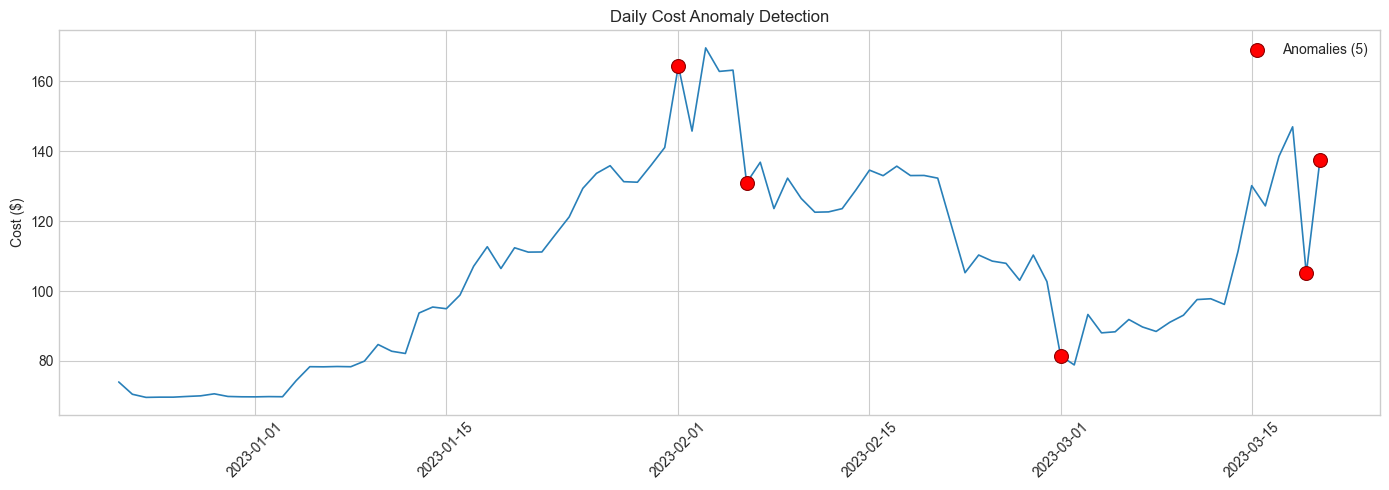

  2023-02-01 — $164.49 (7-day avg was $139.09, ratio: 1.18)
  2023-02-06 — $130.98 (7-day avg was $154.01, ratio: 0.85)
  2023-03-01 — $81.48 (7-day avg was $103.47, ratio: 0.79)
  2023-03-19 — $105.02 (7-day avg was $121.81, ratio: 0.86)
  2023-03-20 — $137.52 (7-day avg was $127.72, ratio: 1.08)


In [84]:
anom_days = ts[ts["anomaly"]==1]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts["ds"], ts["y"], color="#2980b9", lw=1.2)
ax.scatter(anom_days["ds"], anom_days["y"], color="red", s=100, zorder=5,
           edgecolors="darkred", linewidth=0.8, label=f"Anomalies ({n_cost_anom})")
ax.set_title("Daily Cost Anomaly Detection")
ax.set_ylabel("Cost ($)"); ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

for _, row in anom_days.iterrows():
    print(f"  {row['ds'].date()} — ${row['y']:.2f} (7-day avg was ${row['roll_mean_7']:.2f}, ratio: {row['ratio_to_7d']:.2f})")

Drilling into which services drove the cost spikes.

most volatile services (highest daily cost std dev):
  Azure Synapse Analytics             mean=$2.16, std=$10.15, max=$54.95
  Virtual Machines                    mean=$18.42, std=$7.83, max=$49.66
  Advanced Threat Protection          mean=$9.75, std=$6.46, max=$15.12
  Azure Firewall                      mean=$1.91, std=$3.91, max=$14.07
  Redis Cache                         mean=$2.21, std=$3.77, max=$12.10


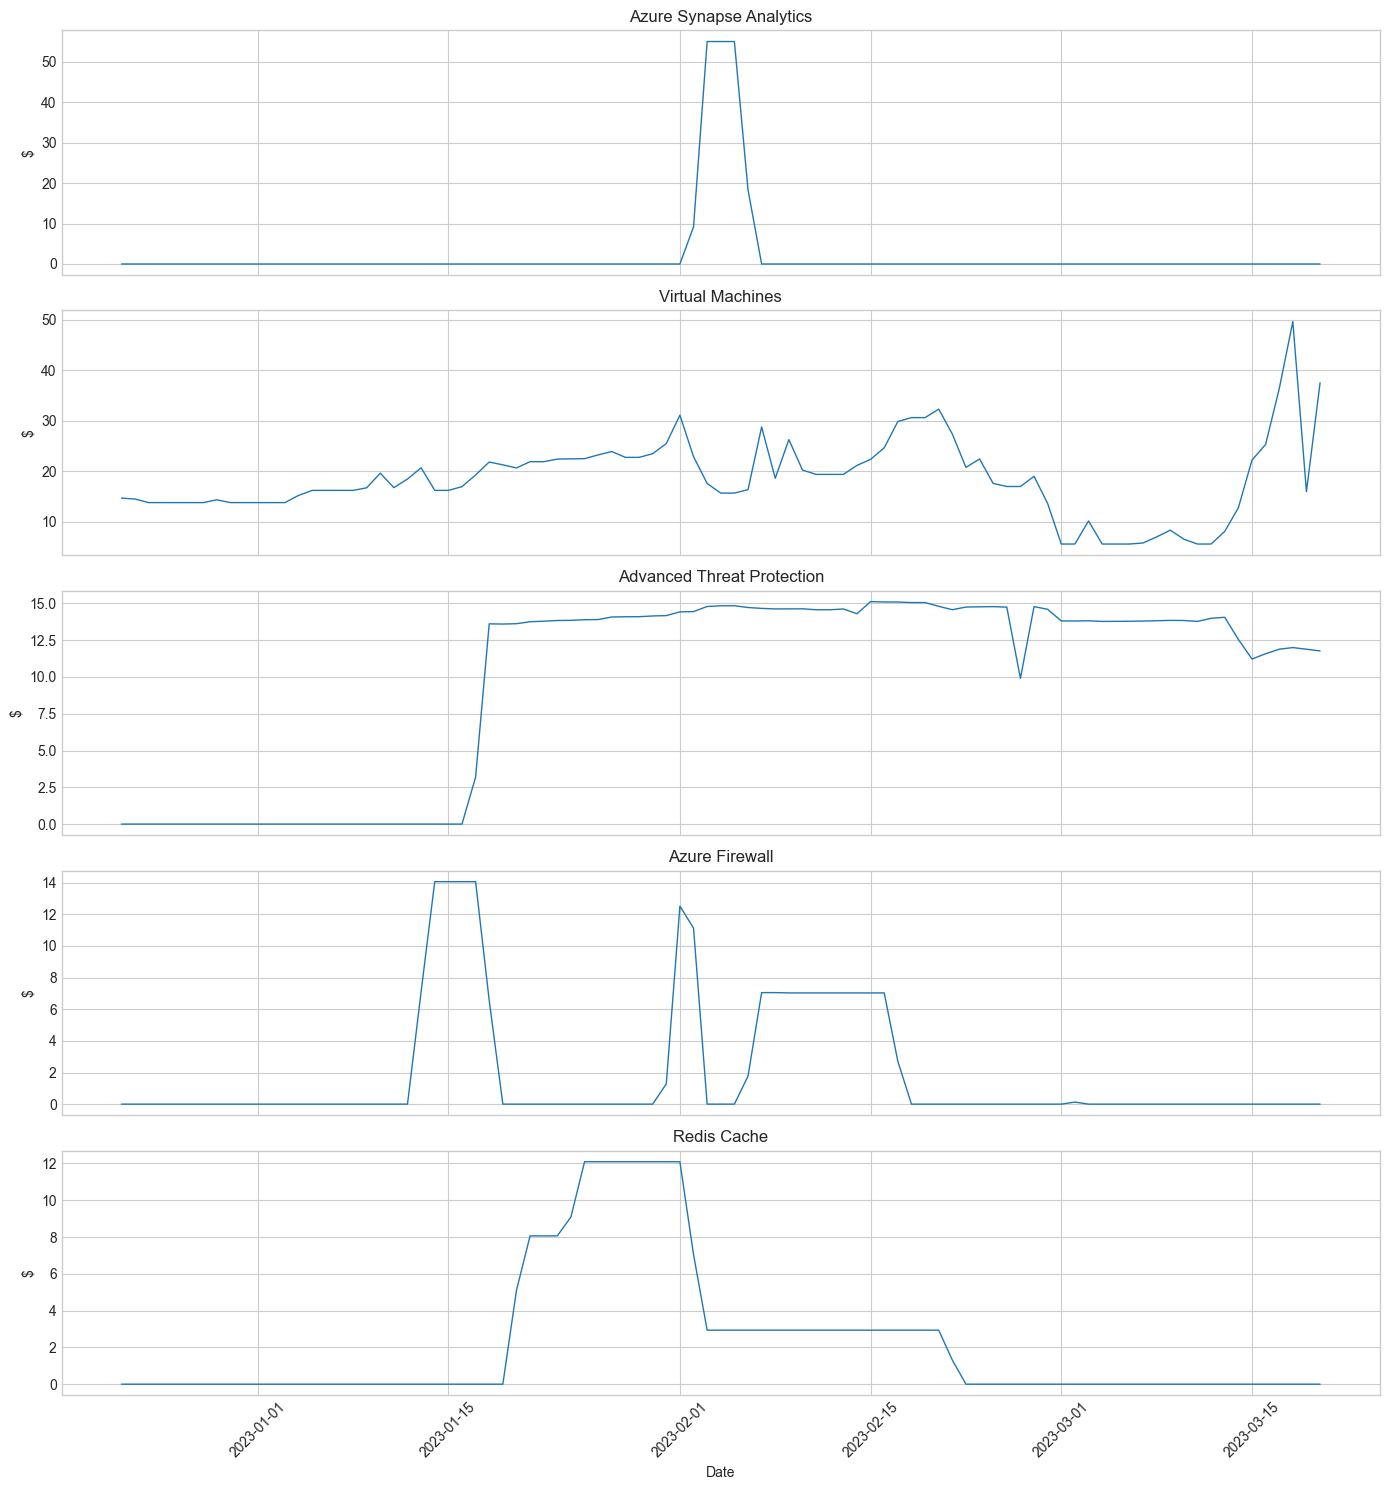

In [85]:
svc_pivot = az.pivot_table(values="CostInBillingCurrency", index="Date",
                            columns="MeterCategory", aggfunc="sum").fillna(0)

# top 5 most volatile services
volatility = svc_pivot.std().sort_values(ascending=False)
top5_volatile = volatility.head(5).index.tolist()

print("most volatile services (highest daily cost std dev):")
for svc in top5_volatile:
    s = svc_pivot[svc]
    print(f"  {svc:35s} mean=${s.mean():.2f}, std=${s.std():.2f}, max=${s.max():.2f}")

fig, axes = plt.subplots(len(top5_volatile), 1, figsize=(14, 3*len(top5_volatile)), sharex=True)
for i, svc in enumerate(top5_volatile):
    axes[i].plot(svc_pivot.index, svc_pivot[svc], lw=1)
    axes[i].set_ylabel("$")
    axes[i].set_title(svc)
axes[-1].set_xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusion

Thus, the project is more or less demonstrative of three things:

1. **You can predict cloud costs really accurately**: the FLAML automl model received R2 of 0.9999 which is insane but makes sense since AWS pricing is deterministic (the more specifics, the more costly). Not such as making a forecast of something noisy such as stock prices.

2. **Forecasting daily bills is harder but doable**: Prophet, as well as ARIMA, remained below 15% MAPE despite having just 89 days of Azure data. I would have much more data on a production system but on a demonstration that this works.

3. **Theres a LOT of money being left on the table**: reserved 40-60 percent and the vast majority of businesses simply default to on-demand since it is less complicated. I believe the most interesting discovery was the extent to which the efficiency scores differ between instance families yielding 10x higher computing rates per dollar than others.

Had more time I would have created a Streamlit dashboard to enable non technical people to make use of it. It would also be appropriate to have 12+ months of billing data as this would make the forecasting much more reliable.

Something I was not certain about: is the 5% Contamination rate of the Isolation Forest the correct choice? It has no ground truth of what is counted as overpriced hence it is not that much of a judgment call. An element to consider in the future.